In [25]:
import numpy as np
import pandas as pd
import joblib
import lightgbm as lgb
from lightgbm import LGBMRegressor, LGBMClassifier
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, TargetEncoder, OrdinalEncoder
import optuna
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import warnings
from sklearn.metrics import f1_score
for warn in [UserWarning, FutureWarning, RuntimeWarning]: warnings.filterwarnings("ignore", category = warn)

## LightGBM

In [20]:

class LightGBM_model: 

    def __init__(self, n_estimators,  max_depth, learning_rate, num_leaves, bagging_fraction, min_child_samples, feature_fraction):

        self.education_encoder = LabelEncoder()
        self.exam_encoder = LabelEncoder()
        self.absence_encoder = LabelEncoder()
        self.disc_encoder = TargetEncoder()
        self.program_encoder = TargetEncoder()
        
        self.place_encoder = OrdinalEncoder(
            categories=[['Без вступительных испытаний', 'Внеконкурсное поступление',
        'Бюджетные', 'Целевые', 'По межправительственным соглашениям',
        'Коммерческие за счет средств вуза', 'Коммерческие', 'Коммерческие места для иностранных граждан']])

        self.grade_model = LGBMRegressor( n_estimators=n_estimators,max_depth=max_depth,
                                          learning_rate=learning_rate, num_leaves=num_leaves,
                                           bagging_fraction=bagging_fraction, min_child_samples=min_child_samples, feature_fraction=feature_fraction, random_state=42, verbose=-1, objective='mae')
        self.type_model = LGBMClassifier( n_estimators=n_estimators,max_depth=max_depth,
                                          learning_rate=learning_rate, num_leaves=num_leaves,
                                           bagging_fraction=bagging_fraction, min_child_samples=min_child_samples, feature_fraction=feature_fraction, random_state=42, verbose=-1)
        self.X_columns = None

    def fit_transform_data(self, data):

        data = data.copy()

        self.education_encoder.fit(['Бакалавриат', 'Магистратура'])
        data['education_level'] = self.education_encoder.transform(data['education_level'])

        self.exam_encoder.fit(['Первая сдача', 'Пересдача по уважительной причине', 'Пересдача', 'Пересдача с комиссией'])
        data['exam_type'] = self.exam_encoder.transform(data['exam_type'])
        data['exam_type_prev'] = self.exam_encoder.transform(data['exam_type_prev'])
        data['target_type'] = self.exam_encoder.transform(data['target_type'])

        self.absence_encoder.fit(['valid', 'invalid', '\\N'])
        data['absence_status'] = self.absence_encoder.transform(data['absence_status'])

        data['discipline'] = self.disc_encoder.fit_transform(data[['discipline']], data['target_grade'])

        data['program'] = self.program_encoder.fit_transform(data[['program']], data['target_grade'])

        data['place_type'] = self.place_encoder.fit_transform(data[['place_type']])

        return data


    def transform_data(self, data):

        data = data.copy()

        data['education_level'] = self.education_encoder.transform(data['education_level'])
        data['exam_type'] = self.exam_encoder.transform(data['exam_type'])
        data['exam_type_prev'] = self.exam_encoder.transform(data['exam_type_prev'])
        data['target_type'] = self.exam_encoder.transform(data['target_type'])
        data['absence_status'] = self.absence_encoder.transform(data['absence_status'])
        data['discipline'] = self.disc_encoder.transform(data[['discipline']])
        data['program'] = self.program_encoder.transform(data[['program']])    
        data['place_type'] = self.place_encoder.transform(data[['place_type']])

        return data

    def fillna_data(self, data):

        data=data.copy()

        data['difficulty_avg_score'] = data.groupby('discipline')['difficulty_avg_score'].transform(lambda x: x.fillna(x.mean()))
        data['difficulty_avg_score'] = data['difficulty_avg_score'].fillna(data['difficulty_avg_score'].mean())
        data['std_deviation'] = data.groupby('discipline')['std_deviation'].transform(lambda x: x.fillna(x.mean()))
        data['std_deviation'] = data['std_deviation'].fillna(data['std_deviation'].mean())
        data['exam_type_prev'] = (data.groupby('student_id')['exam_type_prev'].transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)))
        
        data['exam_type_prev'] = (data.groupby('discipline')['exam_type_prev'].transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)))
        data['exam_type_prev'] = (data['exam_type_prev'].fillna(data['exam_type_prev'].mode()[0]))

        data['grade_prev'] = (data.groupby('student_id')['grade_prev'].transform(lambda x: x.fillna(x.median())))
        data['grade_prev'] = (data.groupby('discipline')['grade_prev'].transform(lambda x: x.fillna(x.median())))
        data['grade_prev'] = (data['grade_prev'].fillna(data['grade_prev'].median()))

        data['difficulty_prev'] = (data.groupby('discipline')['difficulty_prev'].transform(lambda x: x.fillna(x.mean())))
        data['difficulty_prev'] = (data['difficulty_prev'].fillna(data['difficulty_prev'].mean()))

        data['std_deviation_prev'] = (data.groupby('discipline')['std_deviation_prev'].transform(lambda x: x.fillna(x.mean())))
        data['std_deviation_prev'] = (data['std_deviation_prev'].fillna(data['std_deviation_prev'].mean()))


        data['students_responsed_ratio_prev'] = (data.groupby(['program', 'course', 'academic_year'])['students_responsed_ratio_prev'].transform(lambda x: x.fillna(x.mean())))
        data['students_responsed_ratio_prev'] = (data.groupby(['course', 'academic_year'])['students_responsed_ratio_prev'].transform(lambda x: x.fillna(x.mean())))
        data['students_responsed_ratio_prev'] = (data['students_responsed_ratio_prev'].fillna(data['students_responsed_ratio_prev'].mean()))

        data['students_responsed_ratio'] = (data.groupby(['program', 'course', 'academic_year'])['students_responsed_ratio'].transform(lambda x: x.fillna(x.mean())))
        data['students_responsed_ratio'] = (data.groupby(['course', 'academic_year'])['students_responsed_ratio'].transform(lambda x: x.fillna(x.mean())))
        data['students_responsed_ratio'] = (data['students_responsed_ratio'].fillna(data['students_responsed_ratio'].mean()))
        
        return data

    def fit(self, data):

        data = self.fillna_data(data)
        data = self.fit_transform_data(data)

        y_grade = data['target_grade']
        y_type = data['target_type']

        X = data.drop(columns=['target_grade', 'target_type'])

        self.X_columns = X.columns

        self.grade_model.fit(X, y_grade)
        
        self.type_model.fit(X, y_type) 
        

    def predict_grade(self, data):
        data=self.fillna_data(data)
        data = self.transform_data(data)
        X = data[self.X_columns]
        return self.grade_model.predict(X)

    def predict_type(self, data):

        data=self.fillna_data(data)
        data = self.transform_data(data)
        X = data[self.X_columns]
        pred = self.type_model.predict(X)
        return self.exam_encoder.inverse_transform(pred.astype(int))

    def predict_probabs(self, data):

        data=self.fillna_data(data)
        data = self.transform_data(data)
        X = data[self.X_columns]
        pred = self.type_model.predict_proba(X)

        classes = self.exam_encoder.inverse_transform(self.type_model.classes_.astype(int))

        return pd.DataFrame(pred, columns=classes)

    def evaluate(self, data):
        data=self.fillna_data(data)
        data = self.transform_data(data)

        y_grade = data['target_grade']
        y_type = data['target_type']

        X = data.drop(columns=['target_grade', 'target_type'])

        grade_pred = self.grade_model.predict(X)
        type_pred = self.type_model.predict(X)

        mae = mean_absolute_error(y_grade, grade_pred)
        f1 = f1_score(y_type,type_pred,average='weighted')

        return mae, f1

    def feature_importance(self):
        importance = pd.DataFrame({
            'feature': self.X_columns,
            'importance': self.grade_model.feature_importances_
        })

        return importance.sort_values(by='importance', ascending=False)

    def save(self, path):
        joblib.dump(self, path)

    @staticmethod
    def load(path):
        return joblib.load(path)

In [4]:
data = pd.read_csv('total_laggs.csv', low_memory=False)

In [5]:
train_data, testing = train_test_split(
    data,
    test_size=0.3,
    random_state=42
)

val_data, test_data = train_test_split(
    testing,
    test_size=0.5,
    random_state=42
)

### Основные гиперпараметры LightGBM

 1. `learning_rate` $-$ скорость обучения модели.
 2. `n_estimators` $-$ количество деревьев в ансамбле.
 3. `num_leaves` $-$ количество листьев в одном дереве.
 4. `max_depth` $-$ максимальная глубина дерева.
 5. `min_child_samples` $-$ минимальное количество объектов в листе.
 6. `feature_fraction` $-$ доля признаков, используемых при построении дерева.
 7. `bagging_fraction` $-$ доля объектов, используемых для обучения дерева.
 8. `boosting_type` $-$ тип бустинга.


In [6]:
def objective_lGBM(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-3, 0.1, log=True)
    num_leaves = trial.suggest_int("num_leaves", 16, 128)
    max_depth = trial.suggest_int("max_depth", 3, 10)
    n_estimators=trial.suggest_int("n_estimators", 70, 1000)
    bagging_fraction=trial.suggest_float("bagging_fraction", 0.5, 1.0)
    min_child_samples = trial.suggest_int("min_child_samples", 10, 300)
    feature_fraction = trial.suggest_float("feature_fraction", 0.5, 1.0)

    model = LightGBM_model(n_estimators=n_estimators,max_depth=max_depth,
                                          learning_rate=learning_rate, num_leaves=num_leaves,
                                          bagging_fraction=bagging_fraction, min_child_samples=min_child_samples,feature_fraction=feature_fraction)
    model.fit(train_data)
    mae, acc=model.evaluate(val_data)
    return mae

In [7]:
study_ = optuna.create_study(direction='minimize')
optuna.logging.disable_default_handler()
study_.optimize(objective_lGBM, n_trials=150)

best_params_k = study_.best_params
print('Лучшие гиперпараметры:', best_params_k)

[I 2026-06-08 14:27:34,873] A new study created in memory with name: no-name-8f6e3110-9bc8-48c2-9b07-c0575de5a091


Лучшие гиперпараметры: {'learning_rate': 0.06215441032821967, 'num_leaves': 29, 'max_depth': 8, 'n_estimators': 604, 'bagging_fraction': 0.7522409438349638, 'min_child_samples': 286, 'feature_fraction': 0.9990690851708498}


In [9]:
study_.best_value

1.2615675836262619

In [18]:
model = LightGBM_model(learning_rate=0.06215441032821967, num_leaves=29, max_depth=8, n_estimators=604, bagging_fraction=0.7522409438349638, min_child_samples=286, feature_fraction=0.9990690851708498)

model.fit(train_data)

mae_test, f1_test = model.evaluate(test_data)

print('F1 test:', f1_test)
print('MAE test: ', mae_test)

mae_train, f1_train = model.evaluate(train_data)

print('F1 train:', f1_train)
print('MAE train: ', mae_train)

print('feature importance:')
print(model.feature_importance())

F1 test: 0.9310346554208878
MAE test:  1.2252494361200506
F1 train: 0.9871964953475185
MAE train:  1.120421989158789
feature importance:
                          feature  importance
0                      student_id         537
19                 avg_grade_prev         396
10                       grade_10         340
7                      discipline         297
15                     grade_prev         264
1                         program         211
12                  std_deviation         176
18  students_responsed_ratio_prev         170
5                          course         151
16                difficulty_prev         114
13       students_responsed_ratio          95
20                       min_prev          85
11           difficulty_avg_score          78
21                       max_prev          73
3                   academic_year          71
8                          module          55
17             std_deviation_prev          49
4                      place_type  

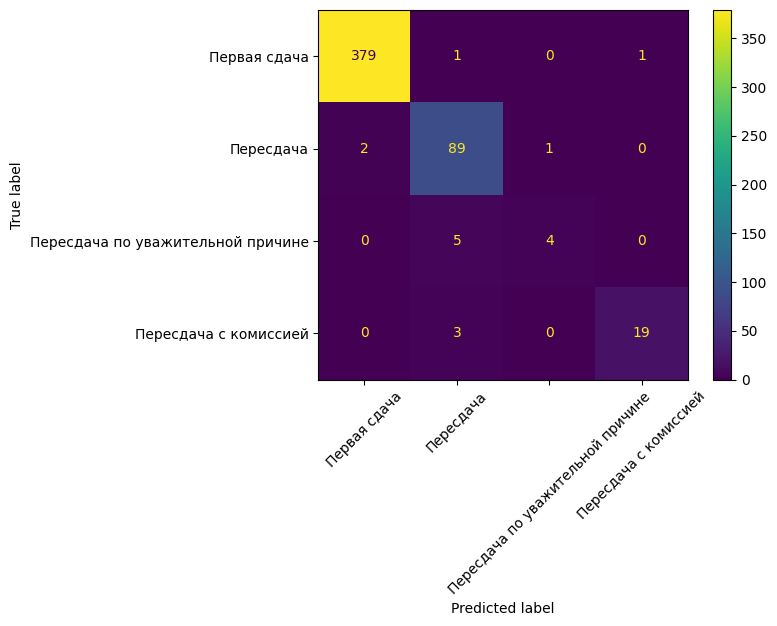

In [113]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = test_data['target_type']
pred=model.predict_type(test_data)
ConfusionMatrixDisplay.from_predictions(
    y_true,
    pred,
    xticks_rotation=45
)

plt.show()

## Random Forest

In [26]:

class RandomForest_model: 

    def __init__(self,n_estimators,criterion, max_depth, min_samples_split,min_samples_leaf, bootstrap, max_samples):

        self.education_encoder = LabelEncoder()
        self.exam_encoder = LabelEncoder()
        self.absence_encoder = LabelEncoder()
        self.disc_encoder = TargetEncoder()
        self.program_encoder = TargetEncoder()
        
        self.place_encoder = OrdinalEncoder(
            categories=[['Без вступительных испытаний', 'Внеконкурсное поступление',
        'Бюджетные', 'Целевые', 'По межправительственным соглашениям',
        'Коммерческие за счет средств вуза', 'Коммерческие', 'Коммерческие места для иностранных граждан']])

        self.grade_model = RandomForestRegressor( n_estimators=n_estimators, max_depth = max_depth, min_samples_split = min_samples_split, 
    min_samples_leaf= min_samples_leaf, bootstrap=bootstrap, max_samples = max_samples, random_state=42, verbose=0)
        self.type_model = RandomForestClassifier( n_estimators=n_estimators,criterion=criterion, max_depth = max_depth, min_samples_split = min_samples_split, 
    min_samples_leaf= min_samples_leaf,bootstrap=bootstrap, max_samples = max_samples, random_state=42, verbose=0)
        self.X_columns = None

    def fit_transform_data(self, data):

        data = data.copy()

        self.education_encoder.fit(['Бакалавриат', 'Магистратура'])
        data['education_level'] = self.education_encoder.transform(data['education_level'])

        self.exam_encoder.fit(['Первая сдача', 'Пересдача по уважительной причине', 'Пересдача', 'Пересдача с комиссией'])
        data['exam_type'] = self.exam_encoder.transform(data['exam_type'])
        data['exam_type_prev'] = self.exam_encoder.transform(data['exam_type_prev'])
        data['target_type'] = self.exam_encoder.transform(data['target_type'])

        self.absence_encoder.fit(['valid', 'invalid', '\\N'])
        data['absence_status'] = self.absence_encoder.transform(data['absence_status'])

        data['discipline'] = self.disc_encoder.fit_transform(data[['discipline']], data['target_grade'])

        data['program'] = self.program_encoder.fit_transform(data[['program']], data['target_grade'])

        data['place_type'] = self.place_encoder.fit_transform(data[['place_type']])

        return data


    def transform_data(self, data):

        data = data.copy()

        data['education_level'] = self.education_encoder.transform(data['education_level'])
        data['exam_type'] = self.exam_encoder.transform(data['exam_type'])
        data['exam_type_prev'] = self.exam_encoder.transform(data['exam_type_prev'])
        data['target_type'] = self.exam_encoder.transform(data['target_type'])
        data['absence_status'] = self.absence_encoder.transform(data['absence_status'])
        data['discipline'] = self.disc_encoder.transform(data[['discipline']])
        data['program'] = self.program_encoder.transform(data[['program']])    
        data['place_type'] = self.place_encoder.transform(data[['place_type']])

        return data

    def fillna_data(self, data):

        data=data.copy()

        data['difficulty_avg_score'] = data.groupby('discipline')['difficulty_avg_score'].transform(lambda x: x.fillna(x.mean()))
        data['difficulty_avg_score'] = data['difficulty_avg_score'].fillna(data['difficulty_avg_score'].mean())
        data['std_deviation'] = data.groupby('discipline')['std_deviation'].transform(lambda x: x.fillna(x.mean()))
        data['std_deviation'] = data['std_deviation'].fillna(data['std_deviation'].mean())
        data['exam_type_prev'] = (data.groupby('student_id')['exam_type_prev'].transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)))
        
        data['exam_type_prev'] = (data.groupby('discipline')['exam_type_prev'].transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)))
        data['exam_type_prev'] = (data['exam_type_prev'].fillna(data['exam_type_prev'].mode()[0]))

        data['grade_prev'] = (data.groupby('student_id')['grade_prev'].transform(lambda x: x.fillna(x.median())))
        data['grade_prev'] = (data.groupby('discipline')['grade_prev'].transform(lambda x: x.fillna(x.median())))
        data['grade_prev'] = (data['grade_prev'].fillna(data['grade_prev'].median()))

        data['difficulty_prev'] = (data.groupby('discipline')['difficulty_prev'].transform(lambda x: x.fillna(x.mean())))
        data['difficulty_prev'] = (data['difficulty_prev'].fillna(data['difficulty_prev'].mean()))

        data['std_deviation_prev'] = (data.groupby('discipline')['std_deviation_prev'].transform(lambda x: x.fillna(x.mean())))
        data['std_deviation_prev'] = (data['std_deviation_prev'].fillna(data['std_deviation_prev'].mean()))


        data['students_responsed_ratio_prev'] = (data.groupby(['program', 'course', 'academic_year'])['students_responsed_ratio_prev'].transform(lambda x: x.fillna(x.mean())))
        data['students_responsed_ratio_prev'] = (data.groupby(['course', 'academic_year'])['students_responsed_ratio_prev'].transform(lambda x: x.fillna(x.mean())))
        data['students_responsed_ratio_prev'] = (data['students_responsed_ratio_prev'].fillna(data['students_responsed_ratio_prev'].mean()))

        data['students_responsed_ratio'] = (data.groupby(['program', 'course', 'academic_year'])['students_responsed_ratio'].transform(lambda x: x.fillna(x.mean())))
        data['students_responsed_ratio'] = (data.groupby(['course', 'academic_year'])['students_responsed_ratio'].transform(lambda x: x.fillna(x.mean())))
        data['students_responsed_ratio'] = (data['students_responsed_ratio'].fillna(data['students_responsed_ratio'].mean()))
        
        return data

    def fit(self, data):

        data = self.fillna_data(data)
        data = self.fit_transform_data(data)

        y_grade = data['target_grade']
        y_type = data['target_type']

        X = data.drop(columns=['target_grade', 'target_type'])

        self.X_columns = X.columns

        self.grade_model.fit(X, y_grade)
        
        self.type_model.fit(X, y_type) 
        

    def predict_grade(self, data):
        data=self.fillna_data(data)
        data = self.transform_data(data)
        X = data[self.X_columns]
        return self.grade_model.predict(X)

    def predict_type(self, data):

        data=self.fillna_data(data)
        data = self.transform_data(data)
        X = data[self.X_columns]
        pred = self.type_model.predict(X)
        return self.exam_encoder.inverse_transform(pred.astype(int))

    def predict_probabs(self, data):

        data=self.fillna_data(data)
        data = self.transform_data(data)
        X = data[self.X_columns]
        pred = self.type_model.predict_proba(X)

        classes = self.exam_encoder.inverse_transform(self.type_model.classes_.astype(int))

        return pd.DataFrame(pred, columns=classes)

    def evaluate(self, data):
        data=self.fillna_data(data)
        data = self.transform_data(data)

        y_grade = data['target_grade']
        y_type = data['target_type']

        X = data.drop(columns=['target_grade', 'target_type'])

        grade_pred = self.grade_model.predict(X)
        type_pred = self.type_model.predict(X)

        mae = mean_absolute_error(y_grade, grade_pred)
        f1 = f1_score(y_type,type_pred,average='weighted')

        return mae, f1

    def feature_importance(self):
        importance = pd.DataFrame({
            'feature': self.X_columns,
            'importance': self.grade_model.feature_importances_
        })

        return importance.sort_values(by='importance', ascending=False)

    def save(self, path):
        joblib.dump(self, path)

    @staticmethod
    def load(path):
        return joblib.load(path)

## Основные гиперпараметры RandomForest 

1. `n_estimators` (default=100) $-$ кол-во деревьев в лесе.


2. `criterion` $-$ функция, которую каждое решающее дерево использует для оценки качества разбиения.

3. `max_depth` $-$ максимальная глубина дерева.

4. `min_samples_split` $-$ минимальное число семплов.

5. `min_samples_leaf` $-$ минимальное число семплов в листе.

6. `bootstrap` $-$ бутстрап выборки.


7. `max_samples` $-$ If bootstrap is True, the number of samples to draw from X to train each base estimator.



In [27]:

def objective_RandomForest(trial):
    n_estimators=trial.suggest_int("n_estimators", 70, 1000)
    criterion=trial.suggest_categorical("criterion", ['gini', 'entropy', 'log_loss'])
    max_depth = trial.suggest_int("max_depth", 3, 10)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10)
    bootstrap=trial.suggest_categorical("bootstrap", [True, False])
    if bootstrap==True: 
        max_samples = trial.suggest_int("max_samples", 10, 300)
    else:
        max_samples=None
    model = RandomForest_model(n_estimators=n_estimators,criterion=criterion, max_depth = max_depth, min_samples_split = min_samples_split, 
    min_samples_leaf=min_samples_leaf, bootstrap=bootstrap, max_samples = max_samples)
    model.fit(train_data)
    mae, acc=model.evaluate(val_data)
    return mae

In [28]:
study_ = optuna.create_study(direction='minimize')
optuna.logging.disable_default_handler()
study_.optimize(objective_RandomForest, n_trials=150)

best_params_k = study_.best_params
print('Лучшие гиперпараметры:', best_params_k)

Лучшие гиперпараметры: {'n_estimators': 106, 'criterion': 'entropy', 'max_depth': 9, 'min_samples_split': 4, 'min_samples_leaf': 4, 'bootstrap': True, 'max_samples': 240}


In [29]:
study_.best_value

1.2881606276115765

In [30]:
model = RandomForest_model(n_estimators=106, criterion='entropy', max_depth=9, min_samples_split=4, min_samples_leaf=4, bootstrap=True, max_samples=240)

model.fit(train_data)

mae_test, f1_test = model.evaluate(test_data)

print('F1 test:', f1_test)
print('MAE test: ', mae_test)

mae_train, f1_train = model.evaluate(train_data)

print('F1 train:', f1_train)
print('MAE train: ', mae_train)

print('feature importance:')
print(model.feature_importance())

F1 test: 0.9382942993984338
MAE test:  1.241811586832574
F1 train: 0.9383171020219959
MAE train:  1.184447493822758
feature importance:
                          feature  importance
10                       grade_10    0.549052
0                      student_id    0.087405
19                 avg_grade_prev    0.059120
7                      discipline    0.050560
15                     grade_prev    0.046615
5                          course    0.033515
1                         program    0.024165
11           difficulty_avg_score    0.021850
12                  std_deviation    0.016410
20                       min_prev    0.015537
16                difficulty_prev    0.014925
17             std_deviation_prev    0.013452
4                      place_type    0.012104
18  students_responsed_ratio_prev    0.010021
13       students_responsed_ratio    0.009089
21                       max_prev    0.008578
8                          module    0.008424
3                   academic_year   

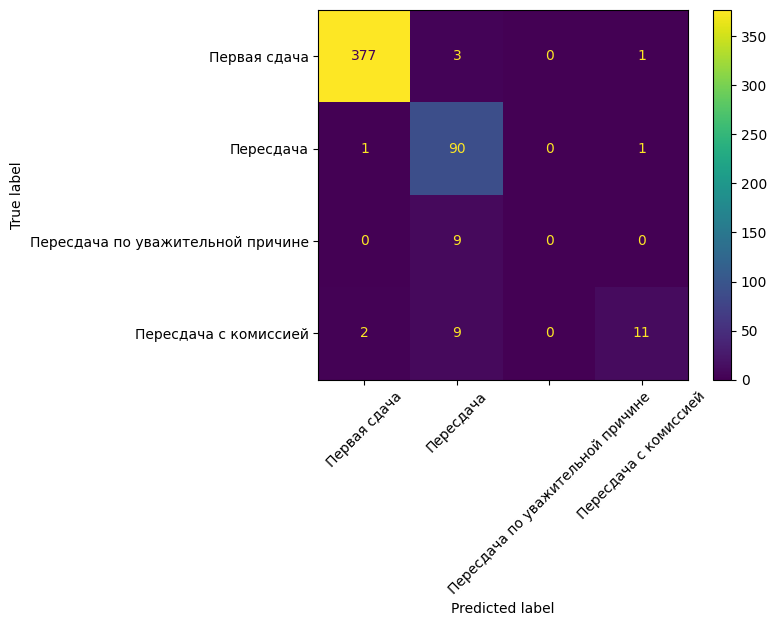

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = test_data['target_type']
pred=model.predict_type(test_data)
ConfusionMatrixDisplay.from_predictions(
    y_true,
    pred,
    xticks_rotation=45
)

plt.show()

### Проверка качества моделей (предсказание константы) 
> Проверим, какие метрики получаются при предсказании константы, чтобы убедиться, что наши модели лучше:

In [31]:
y_true = test_data['target_grade']

for grade in range(1, 11):
    y_pred = [grade] * len(y_true)
    mae = mean_absolute_error(y_true, y_pred)

    print(f'Константая оценка {grade}: MAE = {mae:.4f}')

Константая оценка 1: MAE = 5.0813
Константая оценка 2: MAE = 4.2639
Константая оценка 3: MAE = 3.4821
Константая оценка 4: MAE = 2.8036
Константая оценка 5: MAE = 2.2996
Константая оценка 6: MAE = 2.0417
Константая оценка 7: MAE = 2.1250
Константая оценка 8: MAE = 2.5060
Константая оценка 9: MAE = 3.2044
Константая оценка 10: MAE = 4.0972


Соответственно, предсказание медианной оценки также не даст лучших результатов: 

In [32]:
median_grade = y_true.median()

mae_baseline = mean_absolute_error(
    y_true,
    np.full(len(y_true), median_grade)
)

print("Median:", median_grade)
print("Baseline MAE:", mae_baseline)

Median: 6.0
Baseline MAE: 2.0416666666666665


То же самое для типа оценки: 

In [33]:
y_true = test_data['target_type']

for grade in ['Первая сдача', "Пересдача по уважительной причине", "Пересдача", "Пересдача с комиссией"]:
    y_pred = [grade] * len(y_true)
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f'Константый тип "{grade}": f1 = {f1:.4f}')

Константый тип "Первая сдача": f1 = 0.6509
Константый тип "Пересдача по уважительной причине": f1 = 0.0006
Константый тип "Пересдача": f1 = 0.0564
Константый тип "Пересдача с комиссией": f1 = 0.0037
